In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel('HSI.xlsx')
df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Up', 'Down']
df = df.sort_values('Date').reset_index(drop=True)
#df = df.dropna(subset=['Up', 'Down']).copy()
df['Market_Return'] = df['Close'].pct_change()
 
df

,Date,Open,High,Low,Close,Up,Down,Market_Return
0,2022-02-23,22088.79,22423.51,21983.10,22154.08,0.28,0.72,NaN
1,2022-02-24,23268.03,23376.37,22786.39,22901.56,0.69,0.31,0.033740
2,2022-02-25,22908.10,23046.86,22718.15,22767.18,0.36,0.64,-0.005868
3,2022-02-28,22818.17,22818.17,22406.12,22713.02,0.61,0.49,-0.002379
4,2022-03-01,22739.84,22937.56,22591.73,22761.71,0.49,0.51,0.002144
...,...,...,...,...,...,...,...,...
742,2025-03-06,23987.09,24410.93,23987.09,24369.71,0.60,0.40,0.032868
743,2025-03-07,24182.02,24669.62,24065.01,24231.30,NaN,NaN,-0.005680
744,2025-03-10,24115.98,24292.80,23632.42,23783.49,0.58,0.42,-0.018481
745,2025-03-11,23274.86,23858.61,23238.36,23782.14,0.41,0.59,-0.000057


24369.71
14687.02
19049.84497991968


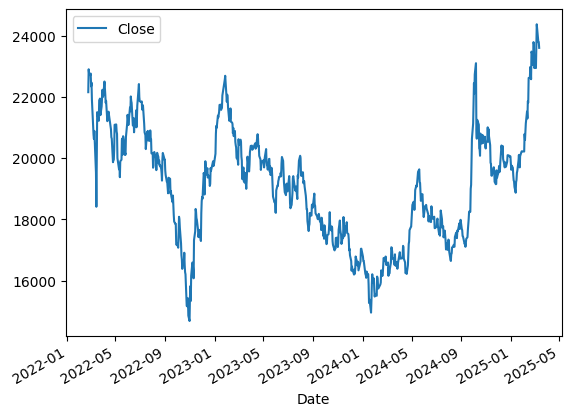

In [87]:
print(df['Close'].max())
print(df['Close'].min())
print(df['Close'].mean())

df.plot(x='Date',y='Close')
plt.show()

0.0002321031170033988
0.01721466943742551
27.327440540167252
0.09081796006316556
-0.0940697270709937


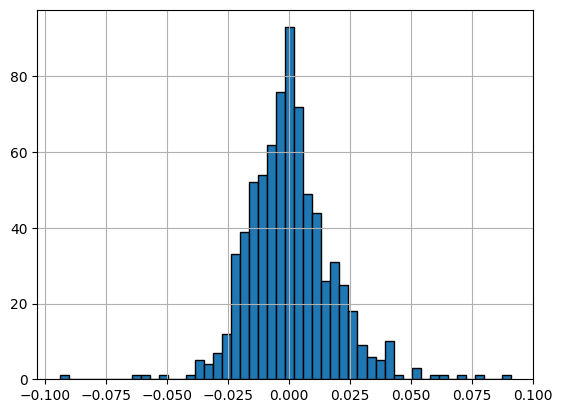

In [88]:
print(df['Market_Return'].mean())
print(df['Market_Return'].std())
print(df['Market_Return'].std()*np.sqrt(252)*100)
print(df['Market_Return'].max())
print(df['Market_Return'].min())

df['Market_Return'].hist(bins=50, edgecolor='black')
plt.show()


In [89]:
print(df['Up'].mean())
print(df['Up'].std())
print(df['Up'].max())
print(df['Up'].min())

0.5406159420289854
0.10199810129286983
0.82
0.24


In [90]:
#df_check = df[df['Up'] > df['Down']]
#print(len(df_check))

#df_check = df[df['Down'] < df['Down']]
#print(len(df_check))

#df_check = df[df['Up'] > 0.6]
#print(len(df_check))

df_check = df[df['Down'] > 0.6]
print(len(df_check))

43


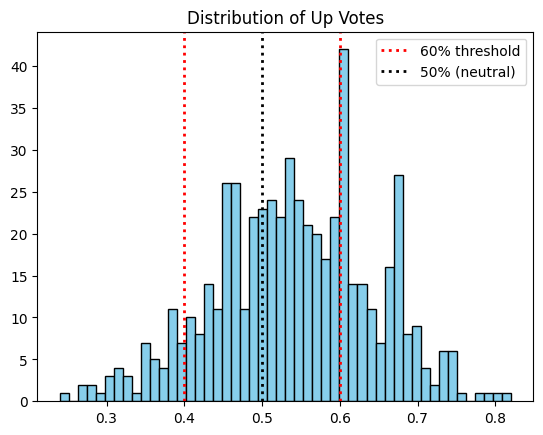

In [91]:
df['Up'].hist(bins=50, edgecolor='black', color = 'skyblue', grid = False)

plt.axvline(0.6, color='red', linestyle=':', linewidth=2, label='60% threshold')
plt.axvline(0.4, color='red', linestyle=':', linewidth=2)
plt.axvline(0.5, color='black', linestyle=':', linewidth=2, label = "50% (neutral)")

plt.legend()
plt.title("Distribution of Up Votes")
plt.show()

In [92]:
df_new = df.dropna(subset=['Up', 'Down']).copy()

corr = df_new['Up'].corr(df_new['Market_Return'])
print(corr)

0.17135147177002422


In [93]:
thresholds   = [0.50, 0.55, 0.60, 0.65]
acc_by_thr   = {}
count_by_thr = {}
for thr in thresholds:
    mask  = (df['Up'] > thr) | (df['Down'] > thr)
    sub   = df[mask].dropna(subset=['Market_Return'])
    right = ((sub['Up'] > thr) & (sub['Market_Return'] > 0)) | ((sub['Down'] > thr) & (sub['Market_Return'] < 0))
    acc_by_thr[thr]   = right.mean()
    count_by_thr[thr] = mask.sum()

print(acc_by_thr)
print(count_by_thr)

{0.5: np.float64(0.5397727272727273), 0.55: np.float64(0.5465116279069767), 0.6: np.float64(0.5538461538461539), 0.65: np.float64(0.5408163265306123)}
{0.5: np.int64(529), 0.55: np.int64(345), 0.6: np.int64(196), 0.65: np.int64(99)}


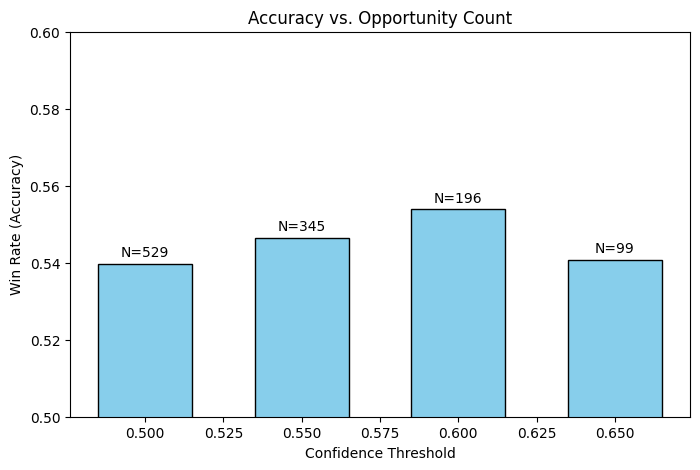

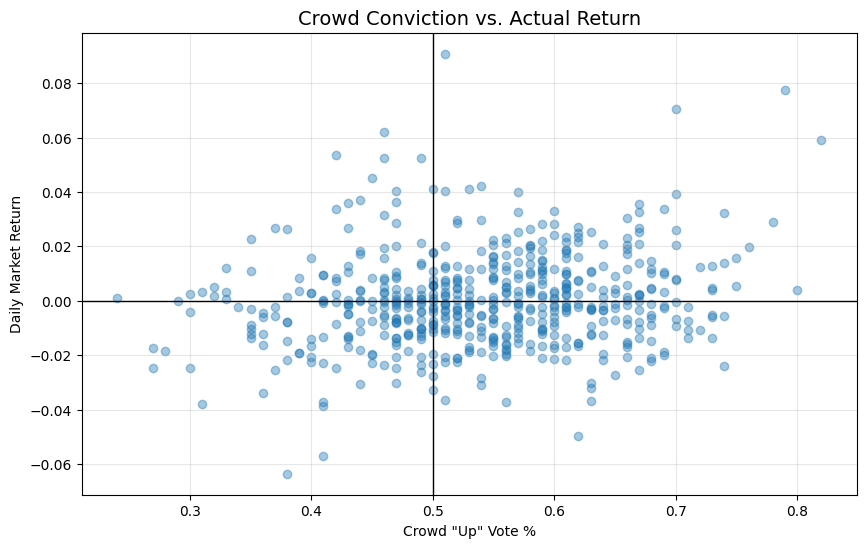

In [94]:
#AI GENERATED

# 1. Extract Data
x = list(acc_by_thr.keys())       # [0.5, 0.55, 0.6, 0.65]
y = list(acc_by_thr.values())     # [0.539, 0.546, 0.553, 0.540]
counts = list(count_by_thr.values()) # [529, 345, 196, 99]

# 2. Create Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(x, y, width=0.03, color='skyblue', edgecolor='black')

# 3. Add "Count" Labels on top of bars
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2,  # X Position (Center)
            bar.get_height() + 0.001,         # Y Position (Just above bar)
            f"N={count}",                     # Text (e.g., "N=196")
            ha='center', va='bottom', fontsize=10)

# 4. Format Axis (Prevent "Exaggeration")
ax.set_ylim(0.50, 0.60)  # Focuses on the relevant range (50% - 60%)
ax.set_xlabel("Confidence Threshold")
ax.set_ylabel("Win Rate (Accuracy)")
ax.set_title("Accuracy vs. Opportunity Count")


plt.show()


import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# 1. The Scatter Plot
# Alpha=0.4 makes the dots transparent so you can see clusters
ax.scatter(df['Up'], df['Market_Return'], alpha=0.4, color='#1f77b4')

# 2. The Quadrant Lines (The "Crosshairs")
ax.axhline(0, color='black', linewidth=1)        # Profit vs Loss
ax.axvline(0.5, color='black', linewidth=1)      # Bullish vs Bearish Majority

# 3. Formatting
ax.set_title('Crowd Conviction vs. Actual Return', fontsize=14)
ax.set_xlabel('Crowd "Up" Vote %')
ax.set_ylabel('Daily Market Return')
ax.grid(True, alpha=0.3)

plt.show()


In [ ]:
thresh = 0.60
 
df['Signal'] = 0
df.loc[df['Up']   > thresh, 'Signal'] =  1
df.loc[df['Down'] > thresh, 'Signal'] = -1
 
df['Strategy']  =  df['Signal'] * df['Market_Return']
df = df.dropna(subset=['Market_Return']).copy()

df['Cum_Market'] = (1 + df['Market_Return']).cumprod() 
df['Cum_Strategy'] = (1 + df['Strategy']).cumprod() 

def calc_metrics(returns, label):
    active        = returns[returns != 0]
    total_return  = (1 + returns).prod() - 1
    annual_return = (1 + total_return) ** (252 / len(returns)) - 1
    win_rate      = (active > 0).mean()
    return dict(label=label, total=total_return, ann_ret=annual_return,
                win_rate=win_rate, n_trades=len(active))
 
m_market     = calc_metrics(df['Market_Return'],     'HSI Buy & Hold')
m_strategy  = calc_metrics(df['Strategy'],  'Follow-the-Crowd')
 
long_days  = (df['Signal'] ==  1).sum()
short_days = (df['Signal'] == -1).sum()
flat_days  = (df['Signal'] ==  0).sum()

print(long_days)
print(short_days)
print(flat_days-195)

print(m_market)
print(m_strategy)
 


153
42
356
{'label': 'HSI Buy & Hold', 'total': np.float64(0.06528052620555758), 'ann_ret': np.float64(0.021591755311251015), 'win_rate': np.float64(0.47050938337801607), 'n_trades': 746}
{'label': 'Follow-the-Crowd', 'total': np.float64(1.1105242888967997), 'ann_ret': np.float64(0.2870030721324319), 'win_rate': np.float64(0.5538461538461539), 'n_trades': 195}


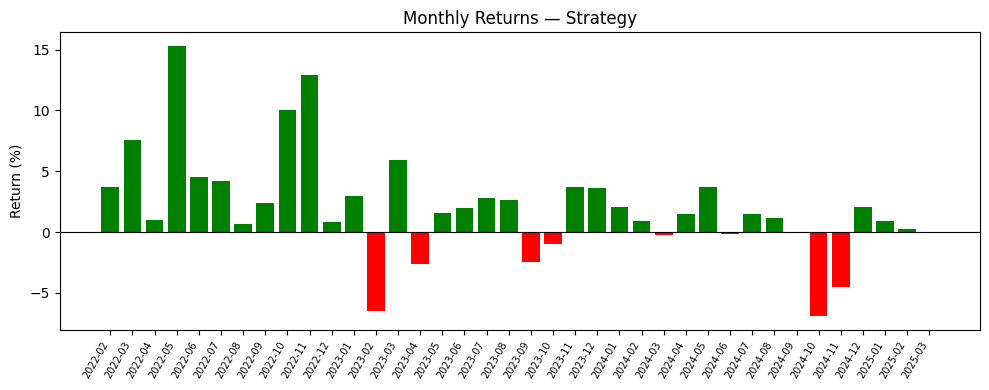

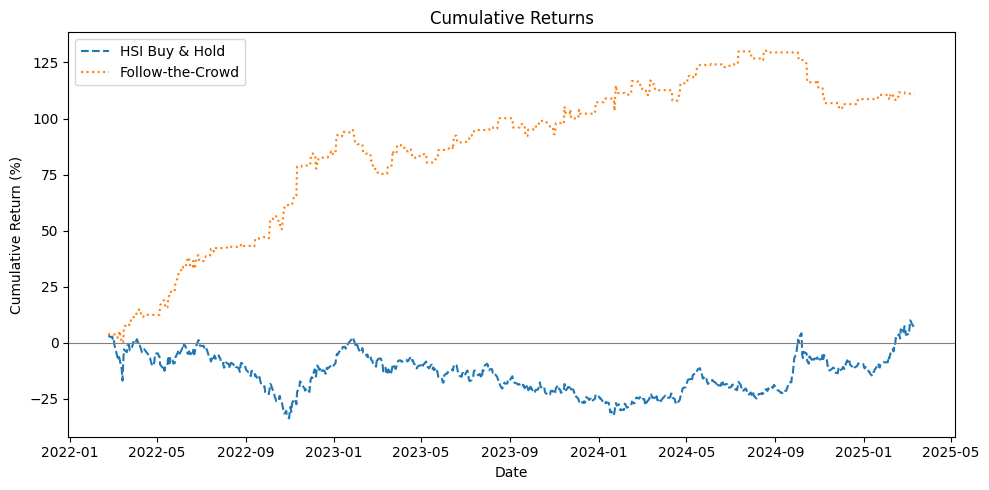

In [97]:
#AI GENERATED

df['YearMonth'] = df['Date'].dt.to_period('M')
monthly = df.groupby('YearMonth')['Strategy'].sum() * 100
colors  = ['green' if v >= 0 else 'red' for v in monthly]
 
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(monthly)), monthly.values, color=colors)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels([str(p) for p in monthly.index], rotation=60, ha='right', fontsize=7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Monthly Returns — Strategy')
ax.set_ylabel('Return (%)')
fig.tight_layout()
plt.show()



fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['Date'], (df['Cum_Market']     - 1) * 100, label='HSI Buy & Hold', linestyle='--')
ax.plot(df['Date'], (df['Cum_Strategy']  - 1) * 100, label='Follow-the-Crowd', linestyle=':')
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_title('Cumulative Returns')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.legend()
fig.tight_layout()
plt.show()